# Import libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the uploaded dataset

In [2]:

file_path = '/content/yield_df.csv'

df = pd.read_csv(file_path)

# Display basic info and first few rows
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB
None
   Unnamed: 0     Area         Item  Year  hg/ha_yield  \
0           0  Albania        Maize  1990        36613   
1           1  Albania     Potatoes  1990        66667   
2           2  Albania  Rice, paddy  1990        23

# Filter rows where Area is India

In [3]:
# Filter rows where Area is India
india_df = df[df['Area'] == 'India'].copy()

# Reset index
india_df.reset_index(drop=True, inplace=True)

# Display sample
print(india_df.head())


   Unnamed: 0   Area     Item  Year  hg/ha_yield  \
0       10502  India  Cassava  1990       205381   
1       10503  India  Cassava  1990       205381   
2       10504  India  Cassava  1990       205381   
3       10505  India  Cassava  1990       205381   
4       10506  India  Cassava  1990       205381   

   average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
0                         1083.0            75000.0     25.58  
1                         1083.0            75000.0     26.88  
2                         1083.0            75000.0     25.79  
3                         1083.0            75000.0     24.10  
4                         1083.0            75000.0     25.25  


In [4]:
print("Missing values in India data:")
print(india_df.isnull().sum())

Missing values in India data:
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [ ]:
numeric_cols = ['hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
india_df[numeric_cols] = india_df[numeric_cols].fillna(india_df[numeric_cols].mean())

In [ ]:
india_df['kg_per_ha_yield'] = india_df['hg/ha_yield'] / 10

# Summary Statistics

In [5]:
print("Summary Statistics:")
print(india_df.describe())

Summary Statistics:
         Unnamed: 0         Year    hg/ha_yield  \
count   4048.000000  4048.000000    4048.000000   
mean   12525.500000  2001.434783   80884.467391   
std     1168.701273     7.064719   95950.224381   
min    10502.000000  1990.000000    6553.000000   
25%    11513.750000  1995.000000   13704.750000   
50%    12525.500000  2001.000000   28124.000000   
75%    13537.250000  2008.000000  112471.000000   
max    14549.000000  2013.000000  385818.000000   

       average_rain_fall_mm_per_year  pesticides_tonnes     avg_temp  
count                         4048.0        4048.000000  4048.000000  
mean                          1083.0       48459.040000    26.012589  
std                              0.0       14997.351972     0.909861  
min                           1083.0       14485.330000    23.260000  
25%                           1083.0       37423.000000    25.460000  
50%                           1083.0       46195.000000    25.980000  
75%                    

# Average yield per crop

In [8]:
avg_yield_crop = india_df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False)

print("Average yield per crop (kg/ha):")
print(avg_yield_crop)

Average yield per crop (kg/ha):
Item
Cassava           282234.434783
Potatoes          182060.304348
Sweet potatoes     87825.173913
Rice, paddy        30295.739130
Wheat              26546.826087
Maize              19305.913043
Soybeans           10354.913043
Sorghum             8452.434783
Name: hg/ha_yield, dtype: float64


# Average Crop Yield in India Over Years

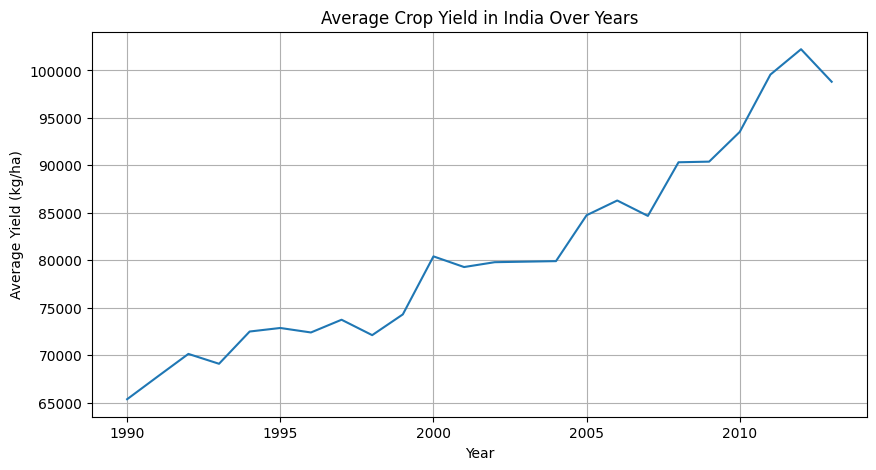

In [11]:
yearly_avg_yield = india_df.groupby('Year')['hg/ha_yield'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x='Year', y='hg/ha_yield', data=yearly_avg_yield)
plt.title('Average Crop Yield in India Over Years')
plt.xlabel('Year')
plt.ylabel('Average Yield (kg/ha)')
plt.grid(True)
plt.show()

# Filter for Rice

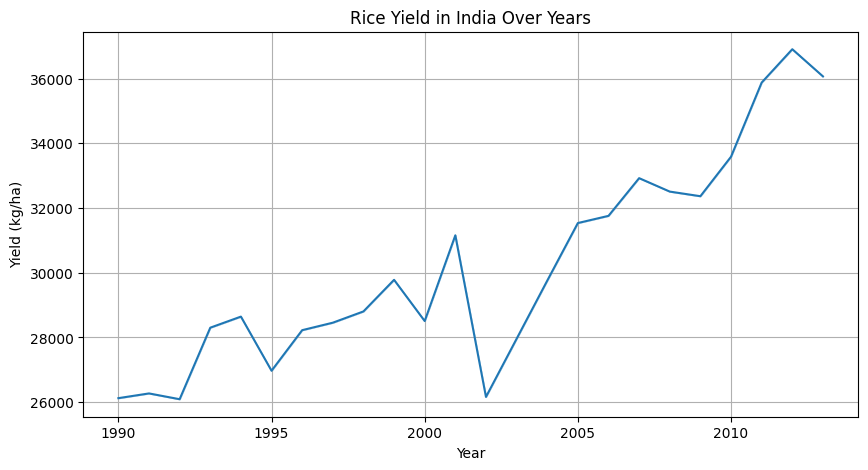

In [13]:

rice_df = india_df[india_df['Item'].str.contains('Rice', case=False)]

plt.figure(figsize=(10,5))
sns.lineplot(x='Year', y='hg/ha_yield', data=rice_df)
plt.title('Rice Yield in India Over Years')
plt.xlabel('Year')
plt.ylabel('Yield (kg/ha)')
plt.grid(True)
plt.show()


#Correlation Matrix

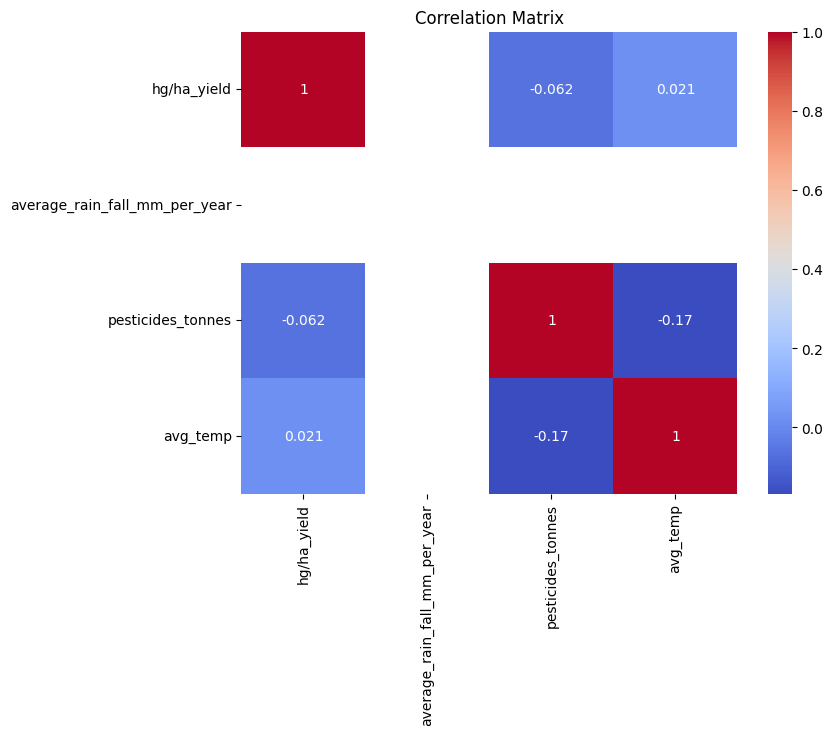

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(india_df[['hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Save cleaned and processed India-only dataset for model training

In [17]:

india_df.to_csv('Processed_India_Crop_Yield_Data.csv', index=False)

print("✅ Processed India data saved as 'Processed_India_Crop_Yield_Data.csv'")

✅ Processed India data saved as 'Processed_India_Crop_Yield_Data.csv'
